# Trialing One At A Time Sensitivity Analysis to the OGGM

We will now apply OAT Sensitivity Analysis to our scalar mass balance calibration technique to see which parameters are most sensitive. This does not include SAFE directly but follows a similar technique to that from the Hydrological example of SAFE's section on OAT Sensitivity Analysis.

In [73]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.sandbox.edu import run_constant_climate_with_bias
from oggm.core.massbalance import mb_calibration_from_scalar_mb, apparent_mb_from_any_mb
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks

# Install python package for interactive visualisation and import required functions:
!pip install -q ipywidgets
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider

# Install SAFE package and import required functions
!pip install SAFEpython

import safepython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
import safepython.plot_functions as pf # Module to visualize the results
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling, AAT_sampling_extend # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
from safepython.util import empiricalcdf
from safepython.util import RMSE

In [74]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-01-12 17:31:06: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-01-12 17:31:06: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-01-12 17:31:06: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-01-12 17:31:07: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-01-12 17:31:07: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-01-12 17:31:07: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [75]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-01-12 17:31:12: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-01-12 17:31:12: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# 1 - One-at-a-time Sensitivity Analysis

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

We cannot compare the runoff specifically to observed runoff since the OGGM does not contain this data.

In [76]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oat_oggm_runner(sample_row):
    
    # Set the parameter values that are being sampled
    melt_f, prcp_fac, temp_bias = sample_row

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=float(melt_f), prcp_fac=float(prcp_fac), temp_bias=float(temp_bias)) # Monthly TI model
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # In-situ mass balance for comparison
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    # Calculate the goodness-of-fit metrics
    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

    return mbdf['mod_mb'], mean_diff, std_diff, rmsd_


We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

Note that not every combination of parameters will work here - some will lead to model crashes.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb,_,_, _ = oat_oggm_runner(param)

    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(mb, label='sim', color='k')
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
    plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], label='obs')
    plt.ylabel('Specific mass balance (mm w.e.)')
    plt.xlabel('Year')
    plt.legend()
    plt.show();

# Create interactive plot, the toggles will change the parameter values 
interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));



interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

The above graph shows the effects that moving each of the parameters has to the mass balance time series.

# GSA - Global Sensitvity Analysis

In [78]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_runner(sample_row):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison


    return np.array([mbdf['mod_mb']]) # Return modelled mass balance time series only


### Running Monte Carlo Simulations

In [79]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -15.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 15.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 2000
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

QQ  = model_execution(oggm_runner, X) # Execute the model for all samples

# Calculate the goodness-of-fit metrics
mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean()) # Calculate mean difference
std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std()) # Calculate standard deviation difference
rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb'])) # Calculate RMSD

YY = np.nan * np.ones((N, 3))

for i, x in enumerate(QQ):
    YY[i,0] = x.mean() - mbdf['in_situ_mb'].mean()
    YY[i,1] = x.std() - mbdf['in_situ_mb'].std()
    YY[i,2] = rmsd(x, mbdf['in_situ_mb'])

2026-01-12 17:31:35: oggm.cfg: PARAMS['melt_f'] changed from `5.0` to `4.114911792596589`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['temp_bias'] changed from `-11.638080704287647` to `-13.71926567577429`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['melt_f'] changed from `4.114911792596589` to `7.241527180134639`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['prcp_fac'] changed from `1.4930072938345726` to `7.815349117924745`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['temp_bias'] changed from `-13.71926567577429` to `-9.144712093370973`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['melt_f'] changed from `7.241527180134639` to `11.255461902912433`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['prcp_fac'] changed from `7.815349117924745` to `9.005881668435558`.
2026-01-12 17:31:35: oggm.cfg: PARAMS['temp_bias'] changed from `-9.144712093370973` to `2.0033495465870885`.
2026-01-12 17:31:36: oggm.cfg: PARAMS['melt_f'] changed from `11.255461902912433` to `11.83315392579163`.
2026-01-12 17:31:36: oggm.cfg: PARAMS['prcp_fa

Plotting the Monte Carlo simulation results and comparison with the observed data.

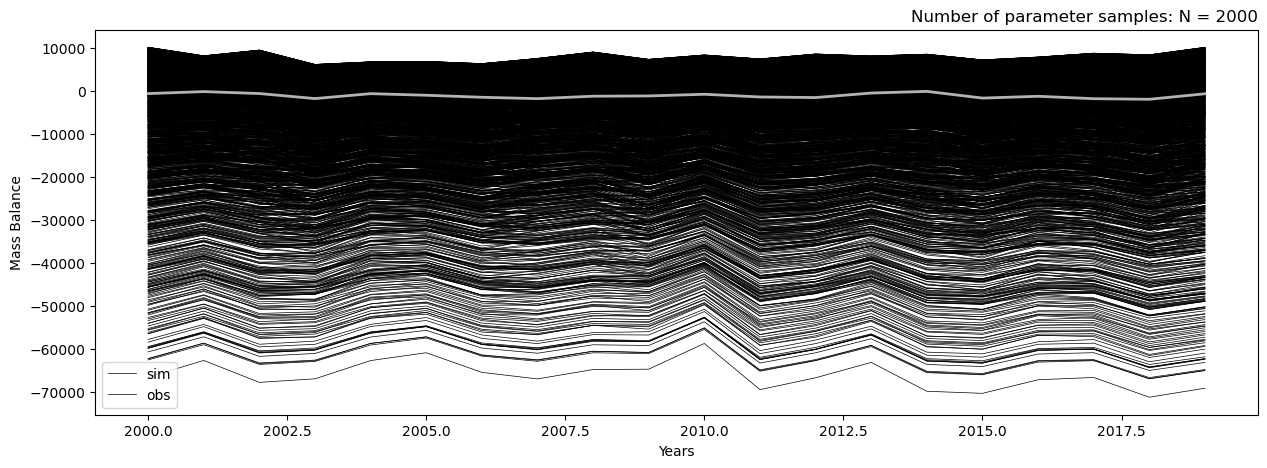

In [80]:
# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf['in_situ_mb'].index.values, np.transpose(QQ), 'k', linewidth = 0.5)
plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], linewidth=2)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim', 'obs'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

### Scatter plot of the goodness-of-fit metrics

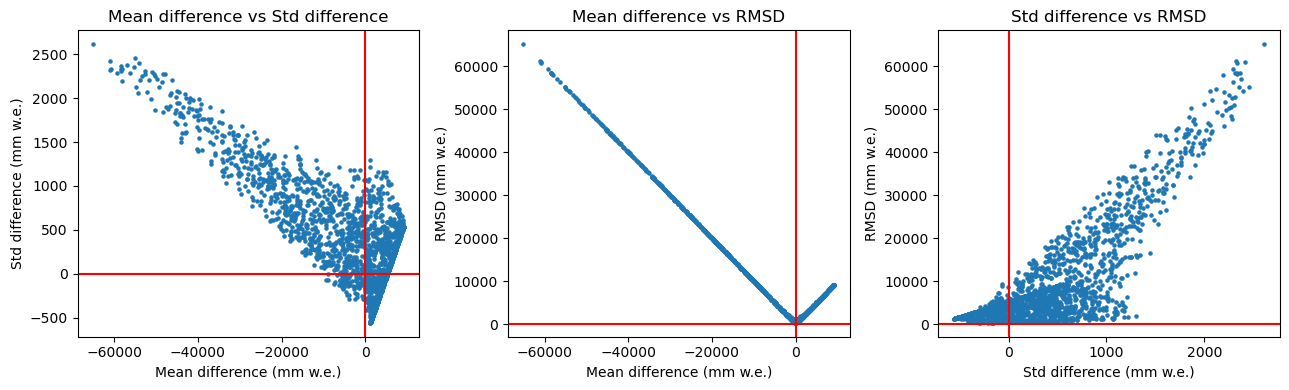

In [81]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean difference vs Std difference'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('Std difference (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.scatter(YY[:,0], YY[:,2], s=5), plt.title('Mean difference vs RMSD'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.scatter(YY[:,1], YY[:,2], s=5), plt.title('Std difference vs RMSD'), plt.xlabel('Std difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?

# TODO: Plot against melt_f, prcp_fac, temp_bias??

In [83]:
    # YY[i,0] = x.mean() - mbdf['in_situ_mb'].mean()
    # YY[i,1] = x.std() - mbdf['in_situ_mb'].std()
    # YY[i,2] = rmsd(x, mbdf['in_situ_mb'])

Y_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2
    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

### Distribution of the model outputs

Now looking at the distribution of the model outputs, here this is the goodness-of-fit parameters.

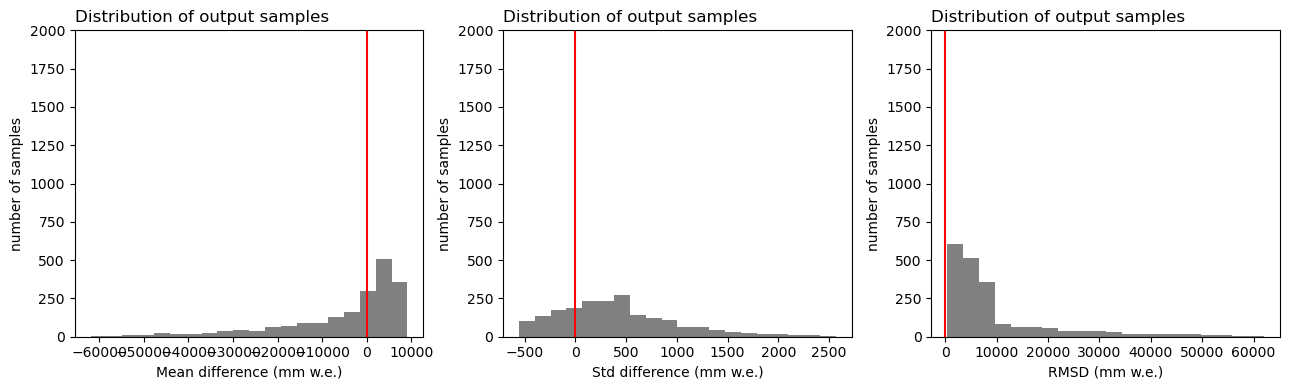

In [15]:
Y_Labels = ['Mean difference (mm w.e.)', 'Std difference (mm w.e.)', 'RMSD (mm w.e.)', 'Mean & Std difference jointly']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[1])

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,2], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[2])

plt.tight_layout()

# Calculating the sensitivity indices

Now we use the input-output samples generated in the previous step to calculate sensitivity indices using **Regional Sensitivity Analysis**. Calculating 3 sets of indices, each measuring the relative importance of the 3 input parameters.

Check - does this tell us first or second/total order interactions? -> See tutorials

TODO: Concatenate targets together? - How is this useful? Seeing how parameters behave together?

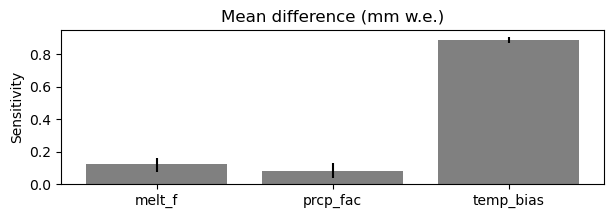

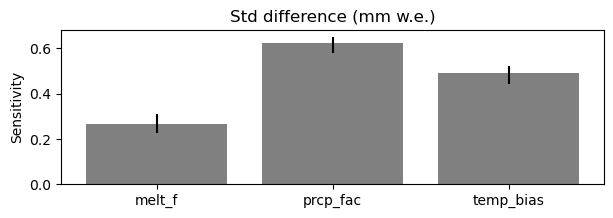

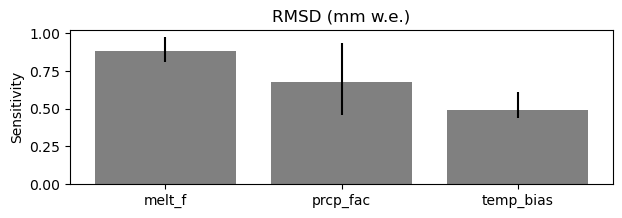

In [16]:
Nboot = 50 # Number of resamples used for bootstrapping

for i in range(3):
    if i==0:
        Y=YY[:,0]
        target=0
    if i==1:
        Y=YY[:,1]
        target=0
    if i==2:
        Y = YY[:,2]
        target = 500 # RMSD cannot be zero here? Minimum working number is around 500, minimum observed value is around 400.

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

# Hydrological Response Metrics - Performance Metrics

Now looking at the hydrological response metrics we have avaliable in the OGGM, mean of runoff and mean of volume.

## One-at-a-time Sensitivity Analysis

In [8]:
import os

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oat_oggm_hydro_runner(gdir_hef, sample_row):
    
    # Set the parameter values that are being sampled
    melt_f, prcp_fac, temp_bias = sample_row

    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    # Setting the parameters in the glacier directory settings, run_with_hydro is a higher level function that reads them from there
    gdir_hef.settings['melt_f'] = float(melt_f) 
    gdir_hef.settings['prcp_fac'] = float(prcp_fac)
    gdir_hef.settings['temp_bias'] = float(temp_bias)

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=float(melt_f), prcp_fac=float(prcp_fac), temp_bias=float(temp_bias)) # Monthly TI model
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # file identifier where the model output is saved
    # Create unique file identifier based on parameters
    file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

    # Delete old file if it exists to force recomputation
    old_file = gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)
    if os.path.exists(old_file):
        os.remove(old_file)

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     init_model_yr=2000,  # Start from spinup year 2000
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()

    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

    # Convert them to megatonnes (instead of kg)
    df_runoff = df_annual[runoff_vars] * 1e-9

    return df_runoff

In [9]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series
from ipywidgets import fixed, interact

def oat_hydro_function(gdir, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    df_runoff = oat_oggm_hydro_runner(gdir, param)

    # Plot the results
    plt.figure(figsize=[15,3])
    df_runoff.sum(axis=1).plot(label="sim")
    plt.ylabel('Runoff (Mt)')
    plt.xlabel('Year')
    plt.legend()

# Create interactive plot, the toggles will change the parameter values 
interact(oat_hydro_function,
         gdir = fixed(gdir_hef),
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

# GSA - Global Sensitivity Analysis

In [52]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_hydro_runner(sample_row, gdir):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    gdir.settings['melt_f'] = float(melt_f)
    gdir.settings['prcp_fac'] = float(prcp_fac)
    gdir.settings['temp_bias'] = float(temp_bias)

    gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- Why does this need to be set for the hydro runs?


    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # file identifier where the model output is saved
    # Create unique file identifier based on parameters
    file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

    # Delete old file if it exists to force recomputation
    old_file = gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)
    if os.path.exists(old_file):
        os.remove(old_file)
        print(f"Deleted old file: {old_file}")

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     init_model_yr=2000,  # Start from spinup year 2000
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()

    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

    # Convert them to megatonnes (instead of kg)
    df_runoff = df_annual[runoff_vars] * 1e-9

    runoff = np.array(df_runoff.sum(axis=1))

    return runoff

### Running Monte Carlo Simulations

In [68]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -15.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 15.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 1000 # Was 2000, TODO- change back to 2000? 1000 takes around 11 mins to run
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

Volume

In [64]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_volume_runner(sample_row, gdir):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    gdir.settings['melt_f'] = float(melt_f)
    gdir.settings['prcp_fac'] = float(prcp_fac)
    gdir.settings['temp_bias'] = float(temp_bias)

    # gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- Why does this need to be set for the hydro runs?

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # 1) Apparent MB must be recomputed with the newly set parameters
    tasks.apparent_mb_from_any_mb(gdir_hef)

    # 2) Inversion: prepare and compute thickness / volume
    tasks.prepare_for_inversion(gdir_hef)
    tasks.mass_conservation_inversion(gdir_hef)

    # 3) Read volume (m³) and convert to km³
    try:
        vol_m3 = tasks.get_inversion_volume(gdir_hef)  # returns total inversion volume
    except Exception:
        # Robust fallback: integrate over inversion flowlines
        fls = gdir_hef.read_pickle('inversion_flowlines')
        vol_m3 = sum(np.sum(fl.thick * fl.width_m * fl.dx) for fl in fls)

    vol_km3 = np.array(float(vol_m3) / 1e9)

    return vol_km3 # Volume in km³ of the glacier

In [69]:
QQ_runoff  = model_execution(oggm_hydro_runner, X, gdir_hef) # Execute the model for all samples
QQ_volume  = model_execution(oggm_volume_runner, X, gdir_hef) # Execute the model for all samples

2026-01-12 15:50:52: oggm.cfg: PARAMS['melt_f'] changed from `14.227121275933426` to `6.962588935897529`.
2026-01-12 15:50:52: oggm.cfg: PARAMS['prcp_fac'] changed from `6.91444607379292` to `7.504243682232262`.
2026-01-12 15:50:52: oggm.cfg: PARAMS['temp_bias'] changed from `10.332349628491635` to `-2.4224192317185587`.


Deleted old file: /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf6.96_pf7.50_tb-2.42.nc


2026-01-12 15:50:53: oggm.cfg: PARAMS['melt_f'] changed from `6.962588935897529` to `14.409563593660407`.
2026-01-12 15:50:53: oggm.cfg: PARAMS['prcp_fac'] changed from `7.504243682232262` to `6.738524123619605`.
2026-01-12 15:50:53: oggm.cfg: PARAMS['temp_bias'] changed from `-2.4224192317185587` to `7.902311837385959`.
2026-01-12 15:50:54: oggm.cfg: PARAMS['melt_f'] changed from `14.409563593660407` to `15.117708835956158`.
2026-01-12 15:50:54: oggm.cfg: PARAMS['prcp_fac'] changed from `6.738524123619605` to `4.275794118665259`.
2026-01-12 15:50:54: oggm.cfg: PARAMS['temp_bias'] changed from `7.902311837385959` to `-3.1517409583948073`.
2026-01-12 15:50:55: oggm.cfg: PARAMS['melt_f'] changed from `15.117708835956158` to `16.174217741474063`.
2026-01-12 15:50:55: oggm.cfg: PARAMS['prcp_fac'] changed from `4.275794118665259` to `4.106108247100478`.
2026-01-12 15:50:55: oggm.cfg: PARAMS['temp_bias'] changed from `-3.1517409583948073` to `11.895554087733885`.
2026-01-12 15:50:55: oggm.cf

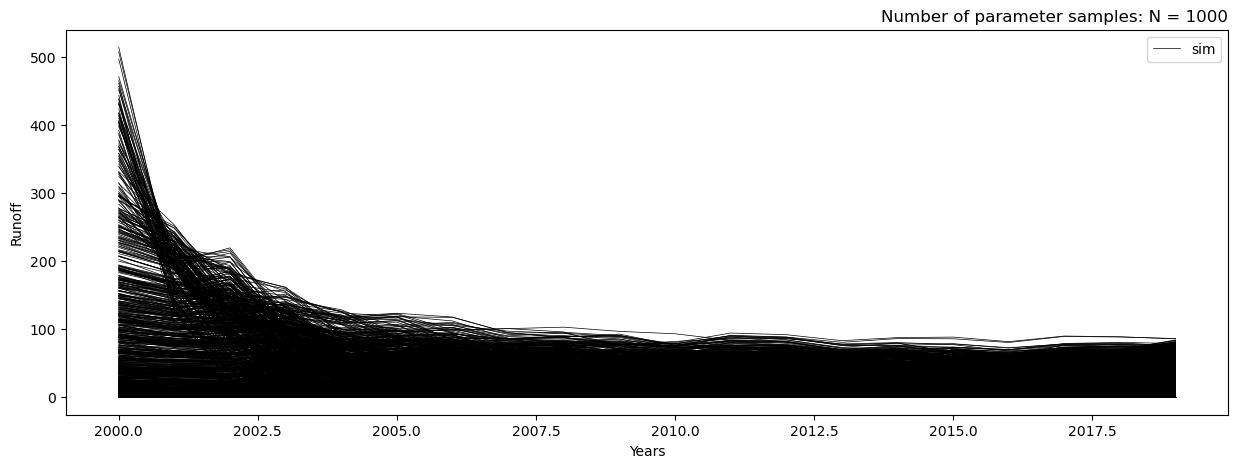

In [70]:
# Plot Monte Carlo (MC) simulations results for thr Runoff and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf.index.values, np.transpose(QQ_runoff), 'k', linewidth = 0.5)
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()


## Sensitivity Analysis

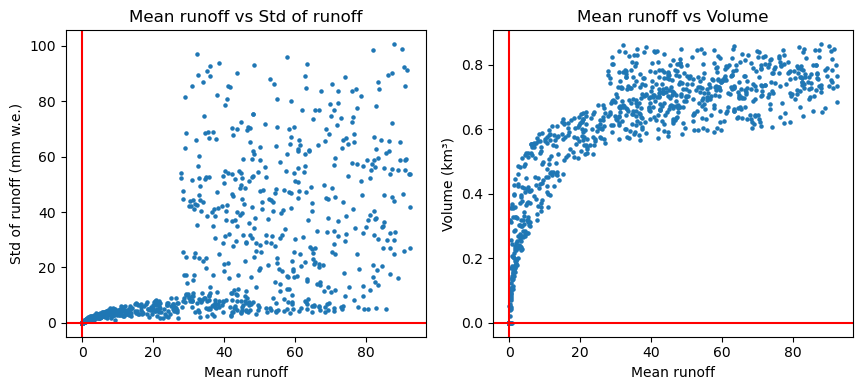

In [ ]:
annual_mean_runoff = np.mean(QQ_runoff, axis=1) # Mean annual runoff for each sample
annual_std_runoff = np.std(QQ_runoff, axis=1) # Std annual runoff for each sample

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(annual_mean_runoff, annual_std_runoff, s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.scatter(annual_mean_runoff, QQ_volume, s=5), plt.title('Mean runoff vs Volume'), plt.xlabel('Mean runoff'), plt.ylabel('Volume (km³)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# compare to x1, x2, x3, x4!!

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?